In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Conectar a la base de datos
conn = sqlite3.connect('../data/inventario_pro.db')

# Cargar las ventas y unir con productos en un solo DataFrame
query = '''
SELECT v.fecha, v.cantidad_vendida, p.nombre, p.categoria, p.costo_unitario 
FROM fact_ventas v
JOIN dim_productos p ON v.producto_id = p.producto_id
'''
df = pd.read_sql_query(query, conn)
df['fecha'] = pd.to_datetime(df['fecha'])

# Ver las primeras filas
print(df.head())

       fecha  cantidad_vendida                      nombre   categoria  \
0 2025-09-28                14           Tintes - Tipo For      Tintes   
1 2026-01-14                 5          Tintes - Tipo Help      Tintes   
2 2026-02-19                 9       Accesorios - Tipo Age  Accesorios   
3 2025-12-02                 4  Accesorios - Tipo Strategy       Telas   
4 2025-08-28                 4        Telas - Tipo Several      Tintes   

   costo_unitario  
0           99.42  
1           63.74  
2           76.14  
3           63.60  
4           32.79  


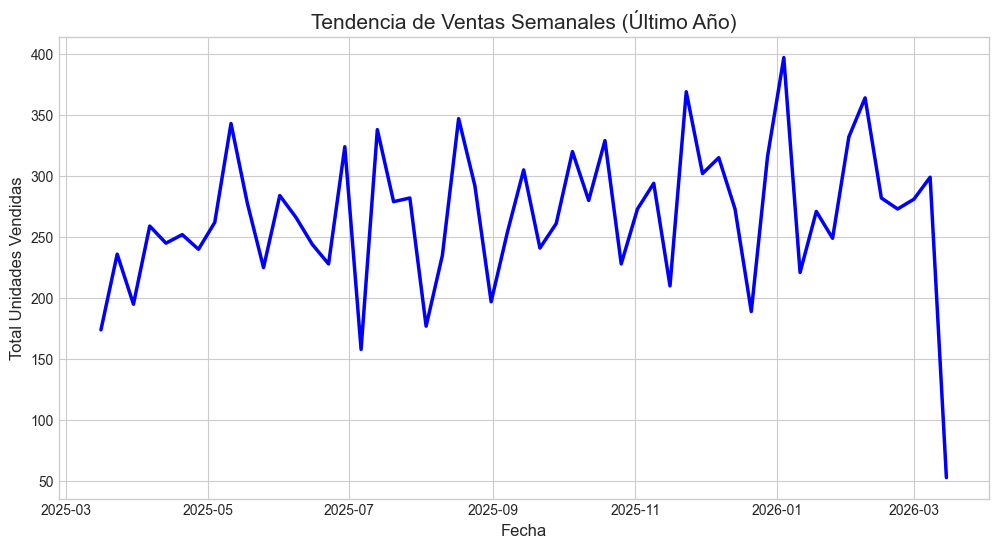

In [9]:
# Configuracion del estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 6))

# Agrupar ventas por semana
df_resample = df.set_index('fecha').resample('W')['cantidad_vendida'].sum().reset_index()

# Grafico
sns.lineplot(data=df_resample, x='fecha', y='cantidad_vendida', color='blue' , linewidth=2.5)
plt.title('Tendencia de Ventas Semanales (Último Año)', fontsize=15)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Total Unidades Vendidas', fontsize=12)
plt.show()

C:\Users\janit\AppData\Local\Temp\ipykernel_13840\145971159.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='viridis')


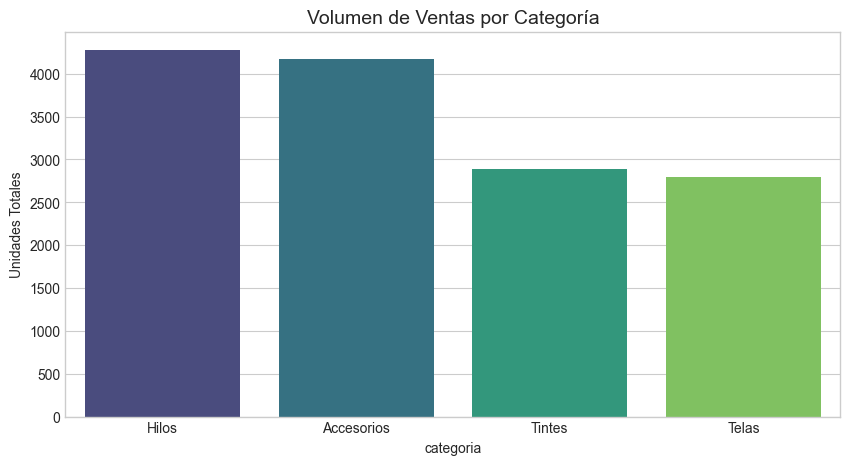

In [10]:
plt.figure(figsize=(10, 5))
cat_sales = df.groupby('categoria')['cantidad_vendida'].sum().sort_values(ascending=False)

sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='viridis')
plt.title('Volumen de Ventas por Categoría', fontsize=14)
plt.ylabel('Unidades Totales')
plt.show()

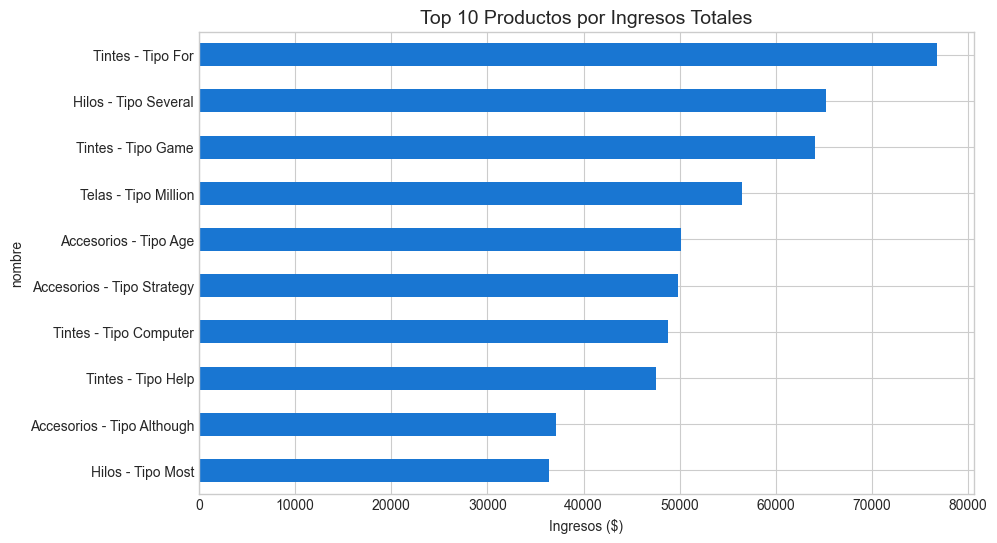

In [5]:
# Crear columna de ingresos (Revenue)
df['ingresos'] = df['cantidad_vendida'] * df['costo_unitario']

top_productos = df.groupby('nombre')['ingresos'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_productos.plot(kind='barh', color='#1976d2')
plt.title('Top 10 Productos por Ingresos Totales', fontsize=14)
plt.xlabel('Ingresos ($)')
plt.gca().invert_yaxis() # Poner el más alto arriba
plt.show()